# ARIM-Academy：ケモメトリクス（教師あり）～ラマンスペクトルによる材料同定と分類～

## 対象読者・前提知識・動作環境

| 項目 | 内容 |
| --- | --- |
| **対象読者** | `RamanSPy-1`（前処理）・`RamanSPy-2`（教師なし）を終えた方。Pythonの基礎文法は理解しているが、教師あり機械学習（分類・交差検証）に初めて取り組む研究者・技術者 |
| **前提知識** | ラマン分光の基礎、前処理、PCAの考え方。統計・機械学習の詳しい予備知識は不要 |
| **動作環境** | Python 3.10 以上、`ramanspy`, `numpy`, `pandas`, `scikit-learn`, `scipy`, `seaborn`, `matplotlib`。Google Colab 推奨 |
| **版・ライセンス** | 本教材のコードは MIT License。データセット OS-127 の利用条件は「データセット」節を参照 |

本ノートブックは、OS-127 のラマンスペクトルを使って **教師あり学習（正解ラベルを使う分類）** を実践します。2つの課題を扱います。

1. **材料同定（スペクトルライブラリ照合）**：ノイズを含む測定スペクトルが、参照ライブラリ中のどの材料かを当てる。分光ライブラリの最も実用的な使い方です。
2. **機能カテゴリ分類**：スペクトルから材料の機能カテゴリ（ドナー／アクセプター／輸送層…）を予測する、より難しい課題。

いずれも、**データリーケージを避けた標準的な機械学習の手順**（訓練/テスト分割、訓練データだけでのスケーリング、交差検証、複数モデルの比較）を守って進めます。

## 本編の目標

`RamanSPy-2` では、ラベルを使わない教師なし学習で「スペクトルの類似度は分子構造を反映する」ことを見ました。本ノートブックでは、**正解ラベルを与えて予測モデルを作る教師あり学習**に進みます。

**実データ特有の課題と対処**：OS-127 は各材料が原則1本（一部2本）の**参照スペクトル集**で、機械学習にはサンプル数が足りません。そこで、実際の測定で生じるゆらぎ（ノイズ、ベースラインのドリフト、強度の変動、波数のわずかなズレ）を模した**データ拡張（data augmentation）**で訓練データを増やします。拡張は**訓練データにだけ**適用し、テストデータには決して混ぜないことでリーケージを防ぎます。

学ぶこと：
- スペクトルのデータ拡張と、その正しい使い方（リーケージ防止）
- 訓練/テスト分割・層化交差検証・訓練データのみでのスケーリング
- 複数の分類器（k近傍・SVM・ランダムフォレスト・LDA・PLS-DA）の比較
- 混同行列・top-k正解率による評価と、その限界の正直な議論

## データセット：OS-127 有機色素ラマン分光データセット

`RamanSPy-2` と同じ **OS-127「有機色素ラマン分光データセット」**（大阪大学、ARIM事業）を用います。45本のスペクトル（41種の材料）に、材料名（`material`）と機能カテゴリ（`family`：5種）が付与されています（`data/OS-127_labels.csv`）。前処理は `RamanSPy-1`・`RamanSPy-2` と同一のパイプラインを使います。

# Google Colabにおける環境設定
Google Colab 環境でなければ実行不要です。

In [ ]:
!pip install ramanspy
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_8_RamanSPy.git
%cd Advanced_Tutorial_8_RamanSPy

### ライブラリのインポート

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import ramanspy as rp

from warnings import filterwarnings
filterwarnings("ignore")

# 再現性のための乱数シード固定
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data" / "spectra"
LABEL_CSV = BASE_DIR / "data" / "OS-127_labels.csv"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. データの読み込みと前処理

`RamanSPy-1`・`RamanSPy-2` と同一の前処理関数・共通グリッドを用い、データ行列 `X`（行=スペクトル、列=波数）とラベル（材料名・機能カテゴリ）を用意します。

In [2]:
# --- RamanSPy-2 と同一の前処理・リサンプリング関数 ---
CROP_REGION = (200, 1800)
SG_WINDOW_LENGTH, SG_POLYORDER = 15, 3
GRID_LOW, GRID_HIGH, GRID_STEP = 900.0, 1600.0, 2.0
COMMON_GRID = np.arange(GRID_LOW, GRID_HIGH + GRID_STEP, GRID_STEP)

def read_csv(csv_filename):
    """OS-127 形式CSVを RamanSPy の Spectrum に変換。"""
    data = pd.read_csv(csv_filename)
    return rp.Spectrum(data["Intensity"].values, data["Wavenumber"].values)

def preprocess(spectrum):
    """RamanSPy-1/2 と同一の前処理パイプライン。"""
    pipeline = rp.preprocessing.Pipeline([
        rp.preprocessing.misc.Cropper(region=CROP_REGION),
        rp.preprocessing.despike.WhitakerHayes(kernel_size=5),
        rp.preprocessing.denoise.SavGol(window_length=SG_WINDOW_LENGTH, polyorder=SG_POLYORDER),
        rp.preprocessing.baseline.ASPLS(),
        rp.preprocessing.normalise.MinMax(),
    ])
    return pipeline.apply(spectrum)

def resample_to_grid(spectrum, grid=COMMON_GRID):
    """共通波数グリッドへ内挿。範囲外は None。"""
    axis = np.asarray(spectrum.spectral_axis, float)
    values = np.asarray(spectrum.spectral_data, float)
    order = np.argsort(axis)
    axis, values = axis[order], values[order]
    if axis.min() > grid.min() or axis.max() < grid.max():
        return None
    return np.interp(grid, axis, values)

In [3]:
files = sorted(DATA_DIR.glob("*.csv"))
labels_all = pd.read_csv(LABEL_CSV).set_index("file")

rows, names = [], []
for csvfile in files:
    resampled = resample_to_grid(preprocess(read_csv(csvfile)))
    if resampled is None:
        continue
    rows.append(resampled)
    names.append(csvfile.name)

X = np.array(rows)
material = labels_all.loc[names, "material"].values
family = labels_all.loc[names, "family"].values

print("データ行列 X:", X.shape)
print("材料数:", len(np.unique(material)), " / スペクトル数:", len(names))
print("family 別本数:", dict(pd.Series(family).value_counts()))

データ行列 X: (42, 351)
材料数: 39  / スペクトル数: 42
family 別本数: {'donor_polymer': np.int64(11), 'acceptor': np.int64(9), 'hole_transport': np.int64(8), 'molecular_dye': np.int64(8), 'electron_transport': np.int64(6)}


## 2. データ拡張（Data Augmentation）

各材料が原則1本しかないため、そのままでは訓練/テストに分けられません。そこで、実測で生じる次のゆらぎを乱数で加えて、1本のスペクトルから多数の「模擬測定」を生成します。

- **ランダムノイズ**：検出器・ショットノイズを模した加法性ガウスノイズ。
- **ベースラインのドリフト**：緩やかな傾き・うねりの残差。
- **強度スケーリング**：レーザー強度・露光の違いによる全体倍率の変動。
- **波数シフト**：装置校正誤差を模した数点の平行移動。

**重要（リーケージ防止）**：拡張は必ず**訓練データにだけ**適用します。テストデータを拡張の元に使うと、実質的に答えを見て学習することになり、性能を過大評価します。

In [4]:
def augment_spectrum(x, n, rng, noise=0.02, drift=0.03, scale=0.05, max_shift=3):
    """1本のスペクトル x から n 本の拡張スペクトルを生成する。"""
    grid = np.linspace(-1, 1, len(x))
    out = []
    for _ in range(n):
        s = rng.normal(1.0, scale)                       # 強度スケーリング
        d = rng.normal(0.0, drift) * grid                # 線形ベースラインドリフト
        e = rng.normal(0.0, noise, size=len(x))          # 加法性ノイズ
        shift = int(rng.integers(-max_shift, max_shift + 1))
        xa = np.clip(np.roll(x, shift) * s + d + e, 0.0, None)
        out.append(xa)
    return np.array(out)

**図1**：拡張の例（元スペクトルと、それから生成した模擬測定5本）

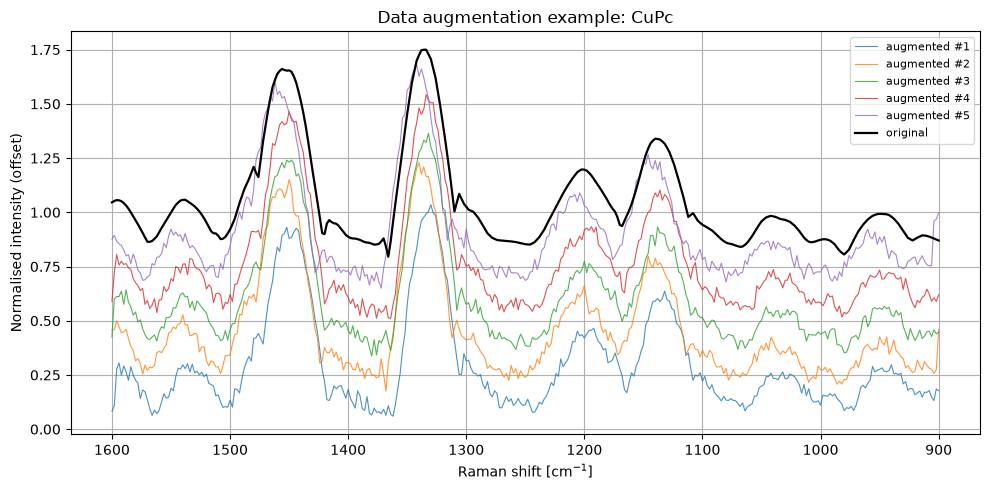

In [5]:
rng_demo = np.random.default_rng(RANDOM_STATE)
idx = list(material).index("CuPc") if "CuPc" in material else 0
aug_demo = augment_spectrum(X[idx], 5, rng_demo)

fig, ax = plt.subplots(figsize=(10, 5))
for i, xa in enumerate(aug_demo):
    ax.plot(COMMON_GRID, xa + i * 0.15, lw=0.8, alpha=0.8, label=f"augmented #{i+1}")
ax.plot(COMMON_GRID, X[idx] + 5 * 0.15, lw=1.6, color="black", label="original")
ax.set_xlabel("Raman shift [cm$^{-1}$]")
ax.set_ylabel("Normalised intensity (offset)")
ax.set_title(f"Data augmentation example: {material[idx]}")
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_augmentation.png", dpi=150)
plt.show()

## 3. 課題A：スペクトルライブラリ照合による材料同定

分光ライブラリの最も実用的な使い方は、「未知試料を測定し、そのスペクトルが**ライブラリ中のどの材料に最も近いか**を当てる」ことです。ここでは、各材料の模擬測定を多数生成し、訓練/テストに分けて、材料名（41クラス）を予測する分類器を比較します。

**プロトコル**
1. 各スペクトルから模擬測定を生成（元の1本＋拡張）。
2. 材料で層化して訓練/テストに分割（テストは拡張の元と重ならないよう別個に生成）。
3. 訓練データだけで標準化（`StandardScaler`）を学習し、テストに適用。
4. 分類器を訓練し、top-1・top-3 正解率を比較。

In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score, top_k_accuracy_score, confusion_matrix

In [7]:
# --- 訓練用・テスト用の模擬測定を、独立した乱数で別々に生成 ---
N_TRAIN_AUG = 30   # 材料あたり訓練用拡張数
N_TEST_AUG = 15    # 材料あたりテスト用拡張数

rng_tr = np.random.default_rng(RANDOM_STATE)
rng_te = np.random.default_rng(RANDOM_STATE + 999)

id_encoder = LabelEncoder().fit(material)
y_id = id_encoder.transform(material)

Xtr_list, ytr_list, Xte_list, yte_list = [], [], [], []
for xi, yi in zip(X, y_id):
    Xtr_list.append(xi[None, :]); ytr_list.append([yi])         # 元スペクトルは参照として訓練へ
    Xtr_list.append(augment_spectrum(xi, N_TRAIN_AUG, rng_tr)); ytr_list.append([yi] * N_TRAIN_AUG)
    Xte_list.append(augment_spectrum(xi, N_TEST_AUG, rng_te));  yte_list.append([yi] * N_TEST_AUG)

X_train = np.vstack(Xtr_list); y_train = np.concatenate(ytr_list)
X_test  = np.vstack(Xte_list); y_test  = np.concatenate(yte_list)
print("訓練:", X_train.shape, " テスト:", X_test.shape, " クラス数:", len(id_encoder.classes_))

# 標準化は訓練データだけで学習（リーケージ防止）
scaler_id = StandardScaler().fit(X_train)
X_train_s = scaler_id.transform(X_train)
X_test_s  = scaler_id.transform(X_test)

訓練: (1302, 351)  テスト: (630, 351)  クラス数: 39


### 分類器の比較（材料同定）
古典的なスペクトル照合に相当する**コサイン距離のk近傍法**を含め、複数の分類器を比較します。`predict_proba` を持つモデルは top-3 正解率（正解が上位3候補に入る割合）も計算します。

In [8]:
id_results = []

def eval_id(name, clf, use_scaled=True, proba=True):
    Xtr, Xte = (X_train_s, X_test_s) if use_scaled else (X_train, X_test)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    top1 = accuracy_score(y_test, pred)
    top3 = np.nan
    if proba and hasattr(clf, "predict_proba"):
        top3 = top_k_accuracy_score(y_test, clf.predict_proba(Xte), k=3, labels=clf.classes_)
    id_results.append({"model": name, "top1_accuracy": top1, "top3_accuracy": top3})
    return clf

# コサインk近傍（スペクトル照合）は生データ（非標準化）で
eval_id("kNN (cosine, k=1)", KNeighborsClassifier(n_neighbors=1, metric="cosine"),
        use_scaled=False, proba=False)
eval_id("SVM (RBF)", SVC(kernel="rbf", C=10, probability=True, random_state=RANDOM_STATE))
eval_id("RandomForest", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))

id_table = pd.DataFrame(id_results)
print(id_table.to_string(index=False))

            model  top1_accuracy  top3_accuracy
kNN (cosine, k=1)       0.992063            NaN
        SVM (RBF)       1.000000            1.0
     RandomForest       0.998413            1.0


### PLS-DA による材料同定
PLS-DA（部分最小二乗判別分析）は、ラベルをワンホット表現の回帰対象とみなして PLS 回帰を当てはめ、最大出力のクラスを予測とする、ケモメトリクスの定番手法です。

In [9]:
# PLS-DA: ラベルをワンホット化して PLS 回帰
Y_onehot = OneHotEncoder(sparse_output=False).fit_transform(y_train.reshape(-1, 1))
pls_id = PLSRegression(n_components=15).fit(X_train_s, Y_onehot)
pls_pred = pls_id.predict(X_test_s).argmax(axis=1)
pls_top1 = accuracy_score(y_test, pls_pred)
id_table = pd.concat([id_table, pd.DataFrame([{"model": "PLS-DA", "top1_accuracy": pls_top1, "top3_accuracy": np.nan}])],
                     ignore_index=True)
print(f"PLS-DA top-1 accuracy: {pls_top1:.3f}")

PLS-DA top-1 accuracy: 0.754


**図2**：材料同定モデルの比較（top-1 正解率）

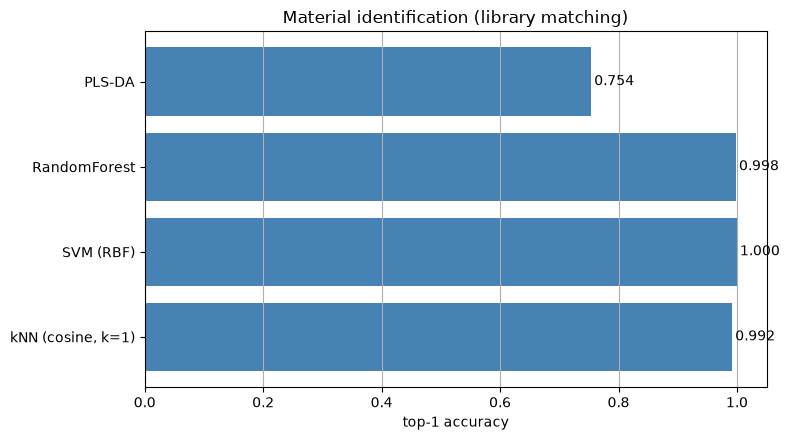

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(id_table["model"], id_table["top1_accuracy"], color="steelblue")
for i, v in enumerate(id_table["top1_accuracy"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlim(0, 1.05)
ax.set_xlabel("top-1 accuracy")
ax.set_title("Material identification (library matching)")
ax.grid(True, axis="x")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_identification.png", dpi=150)
plt.show()

### 【考察・限界】材料同定の結果をどう読むか

- コサインk近傍・SVM・ランダムフォレストとも高い top-1 正解率を示し、ノイズを含む測定でも参照ライブラリ照合で材料をよく同定できることが分かります。
- **重要な限界**：ここでのテストスペクトルは、訓練と同じ元の参照スペクトルから**データ拡張で生成した模擬測定**です。独立に再測定した実データではないため、実運用での正解率はこれより低くなります。真の性能評価には、同一材料の**独立した繰り返し測定**が必要です（OS-127 には各材料の複製測定が少ないため、本教材では拡張で代替しています）。
- それでも、この枠組みは「ライブラリ照合による同定」というワークフローと、リーケージを避けた評価手順を学ぶうえで有効です。

## 4. 課題B：機能カテゴリ（family）の分類

次に、より難しい課題として、スペクトルから材料の**機能カテゴリ（5クラス）**を予測します。`RamanSPy-2` で見たとおり、ラマンの類似度は分子構造を反映し機能とは別軸なので、この課題は本質的に難しいことが予想されます。

サンプルが42本と少ないため、**層化5分割交差検証（StratifiedKFold）**で評価します。各フォールドで、
- 訓練側だけをデータ拡張し、
- 訓練側だけで標準化を学習し、
- 実測のテスト側（拡張しない）で評価
することで、リーケージを厳密に防ぎます。

In [11]:
from sklearn.model_selection import StratifiedKFold

fam_encoder = LabelEncoder().fit(family)
y_fam = fam_encoder.transform(family)
class_names = fam_encoder.classes_

def augment_train(Xtr, ytr, n_per, rng):
    """訓練データだけを拡張（元＋拡張を返す）。"""
    Xa, ya = [Xtr], [ytr]
    for xi, yi in zip(Xtr, ytr):
        Xa.append(augment_spectrum(xi, n_per, rng)); ya.append(np.full(n_per, yi))
    return np.vstack(Xa), np.concatenate(ya)

def cv_family(name, make_clf, n_per=15):
    """層化5分割CVで family 分類を評価（フォールド内で拡張・標準化）。"""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    accs, y_true_all, y_pred_all = [], [], []
    rng = np.random.default_rng(RANDOM_STATE)
    for tr, te in skf.split(X, y_fam):
        Xtr_a, ytr_a = augment_train(X[tr], y_fam[tr], n_per, rng)
        scaler = StandardScaler().fit(Xtr_a)
        clf = make_clf()
        clf.fit(scaler.transform(Xtr_a), ytr_a)
        pred = clf.predict(scaler.transform(X[te]))
        accs.append(accuracy_score(y_fam[te], pred))
        y_true_all.extend(y_fam[te]); y_pred_all.extend(pred)
    return np.mean(accs), np.std(accs), np.array(y_true_all), np.array(y_pred_all)

In [12]:
fam_models = {
    "kNN (k=3)":      lambda: KNeighborsClassifier(n_neighbors=3),
    "SVM (RBF)":      lambda: SVC(kernel="rbf", C=10, random_state=RANDOM_STATE),
    "RandomForest":   lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "LDA":            lambda: LinearDiscriminantAnalysis(),
}

fam_results = []
preds_by_model = {}
for name, make in fam_models.items():
    mean, std, yt, yp = cv_family(name, make)
    fam_results.append({"model": name, "cv_accuracy": mean, "cv_std": std})
    preds_by_model[name] = (yt, yp)

fam_table = pd.DataFrame(fam_results).sort_values("cv_accuracy", ascending=False)
print(fam_table.to_string(index=False))
print(f"\n参考：多数派クラスを常に予測するベースライン = {pd.Series(family).value_counts(normalize=True).max():.3f}")

       model  cv_accuracy   cv_std
   SVM (RBF)     0.519444 0.146355
   kNN (k=3)     0.450000 0.070601
RandomForest     0.427778 0.140381
         LDA     0.241667 0.263757

参考：多数派クラスを常に予測するベースライン = 0.262


**図3**：機能カテゴリ分類モデルの比較（5分割CV正解率、エラーバー=標準偏差）

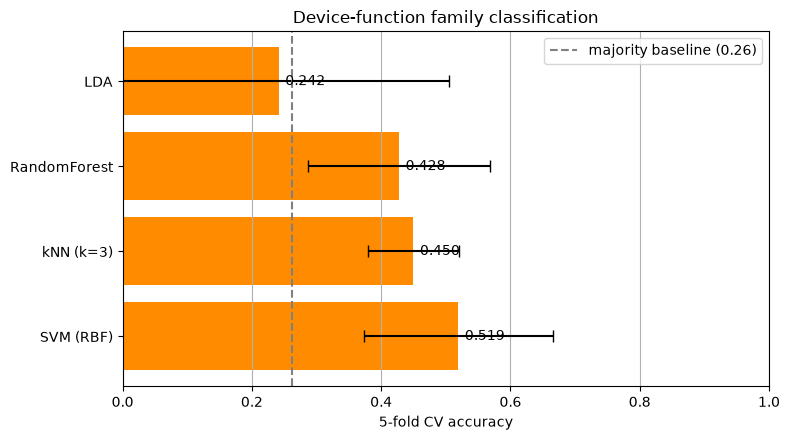

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fam_table["model"], fam_table["cv_accuracy"], xerr=fam_table["cv_std"],
        color="darkorange", capsize=4)
for i, v in enumerate(fam_table["cv_accuracy"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
baseline = pd.Series(family).value_counts(normalize=True).max()
ax.axvline(baseline, color="gray", ls="--", label=f"majority baseline ({baseline:.2f})")
ax.set_xlim(0, 1.0)
ax.set_xlabel("5-fold CV accuracy")
ax.set_title("Device-function family classification")
ax.legend()
ax.grid(True, axis="x")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_family_models.png", dpi=150)
plt.show()

### 混同行列（最良モデル）
最良モデルの交差検証予測をまとめた混同行列を表示します。`confusion_matrix(y_true, y_pred)` の引数順（正解が先、予測が後）に注意してください。

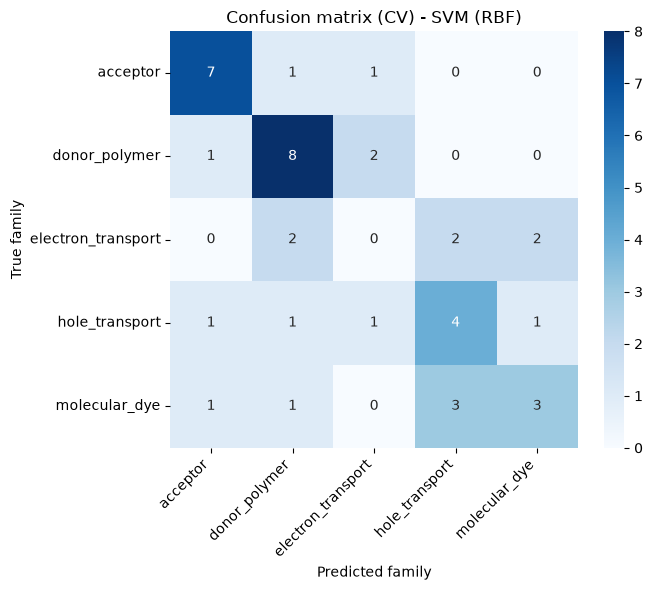

In [14]:
best_name = fam_table.iloc[0]["model"]
yt, yp = preds_by_model[best_name]
cm = confusion_matrix(yt, yp)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted family")
ax.set_ylabel("True family")
ax.set_title(f"Confusion matrix (CV) - {best_name}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_confusion.png", dpi=150)
plt.show()

### 【考察】機能カテゴリ分類が難しい理由

- 正解率は多数派ベースラインを上回るものの、材料同定（課題A）に比べて明確に低くなります。これは `RamanSPy-2` の結論——**ラマンスペクトルは分子構造の指紋であり、デバイス機能（family）とは別軸**——と整合します。
- 混同行列を見ると、構造の異なる同一カテゴリ（例：ペリレンジイミド系と縮環A–D–A系がともに `acceptor`）が取り違えられやすいことが読み取れます。
- サンプル数が42本と少なく、フォールドごとの変動（標準偏差）も大きい点に注意が必要です。結論は「傾向」として扱い、断定を避けます。

## 5. 手法・課題の総合比較

2つの課題（材料同定・機能分類）と各モデルの結果を横並びにまとめます。

In [15]:
summary = pd.DataFrame({
    "task": [f"材料同定 ({len(id_encoder.classes_)}クラス)"] * len(id_table) + [f"機能分類 ({len(class_names)}クラス)"] * len(fam_table),
    "model": list(id_table["model"]) + list(fam_table["model"]),
    "accuracy": list(id_table["top1_accuracy"]) + list(fam_table["cv_accuracy"]),
    "note": (["top-1 / 拡張テスト"] * len(id_table)) + (["5-fold CV"] * len(fam_table)),
})
print(summary.to_string(index=False))
summary.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

        task             model  accuracy          note
材料同定 (39クラス) kNN (cosine, k=1)  0.992063 top-1 / 拡張テスト
材料同定 (39クラス)         SVM (RBF)  1.000000 top-1 / 拡張テスト
材料同定 (39クラス)      RandomForest  0.998413 top-1 / 拡張テスト
材料同定 (39クラス)            PLS-DA  0.753968 top-1 / 拡張テスト
 機能分類 (5クラス)         SVM (RBF)  0.519444     5-fold CV
 機能分類 (5クラス)         kNN (k=3)  0.450000     5-fold CV
 機能分類 (5クラス)      RandomForest  0.427778     5-fold CV
 機能分類 (5クラス)               LDA  0.241667     5-fold CV


## 6. まとめ

本ノートブックでは、OS-127 のラマンスペクトルを用いて教師あり学習を実践しました。

- **データ拡張**で参照スペクトル集を機械学習に使える形に増やし、**訓練データにのみ拡張・標準化を適用**してリーケージを防ぎました。
- **課題A（材料同定）**：ライブラリ照合として高い正解率。分光ライブラリの実用的な使い方を示しました（ただしテストは拡張データであり、実運用値はより低い）。
- **課題B（機能分類）**：構造と機能が別軸のため本質的に難しく、正解率は限定的。`RamanSPy-2` の教師なしの知見と整合します。
- 複数の分類器（k近傍・SVM・RF・LDA・PLS-DA）を同一手順で比較し、モデル選択の基礎を学びました。

3部作（`RamanSPy-1`→`2`→`3`）を通じて、**前処理 → 教師なし探索 → 教師あり予測**というラマンケモメトリクスの一連の流れを、実データで体験しました。

## 7. 本ノートブックで扱っていないこと（今後の課題）

- **独立した繰り返し測定**：本教材はデータ拡張で測定ゆらぎを模擬しました。真の汎化性能評価には、同一材料の独立再測定が必要です。
- **ハイパーパラメータ最適化**：各分類器のパラメータは代表値です。入れ子交差検証によるチューニングは扱っていません。
- **次元削減との組み合わせ**：PCA/PLS の成分数や特徴選択の最適化。
- **深層学習**：1次元CNNなどのスペクトル向けモデルは扱っていません（サンプル数の制約が大きい）。
- **拡張の妥当性検証**：拡張パラメータ（ノイズ・ドリフト量）が実際の測定ゆらぎと合っているかの検証。

## 8. 演習問題

1. **拡張量の影響**：`augment_spectrum` の `noise`・`drift` を変えて、材料同定・機能分類の正解率がどう変わるか調べてください。拡張が強すぎると何が起きますか。
2. **リーケージの実験**：（悪い例として）標準化を全データで `fit` してから分割した場合と、訓練のみで `fit` した場合で、機能分類のCV正解率がどう変わるか比較してください。
3. **別の分類対象**：`family` の代わりに `excitation_nm`（532 / 785 nm）を予測対象にして分類してみてください。これは材料の性質ではなく測定条件の分類です。正解率が高い場合、モデルは何を手がかりにしていると考えられますか。
4. **top-k の解釈**：材料同定で top-1 と top-3 の差は何を意味しますか。ライブラリ照合の実務では top-3 が役立つ場面を挙げてください。
5. **PLS-DA の成分数**：`PLSRegression(n_components=...)` を 5・15・30 と変えて材料同定の正解率を比較し、過学習の兆候を考察してください。